<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ резюме из HeadHunter
   

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Исследование структуры данных

1. Прочитайте данные с помощью библиотеки Pandas. Совет: перед чтением обратите внимание на разделитель внутри файла. 

In [15]:
import os
print(os.getcwd())

C:\Users\User\skill


In [10]:
#Данные из резюме соискателей HH.ru 
hh_data = pd.read_csv('data\dst-3.0_16_1_hh_database.csv', sep=';')
#Данные о курсе валют 
exchange_rates_data = pd.read_csv('data\ExchangeRates.csv', sep=',')

2. Выведите несколько первых (последних) строк таблицы, чтобы убедиться в том, что ваши данные не повреждены. Ознакомьтесь с признаками и их структурой.

In [16]:
display(hh_data.head())
display(hh_data.tail())

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
0,"Мужчина , 39 лет , родился 27 ноября 1979",29000 руб.,Системный администратор,"Советск (Калининградская область) , не готов к...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, ва...",Опыт работы 16 лет 10 месяцев Август 2010 — п...,"МАОУ ""СОШ № 1 г.Немана""",Системный администратор,Неоконченное высшее образование 2000 Балтийск...,16.04.2019 15:59,Имеется собственный автомобиль
1,"Мужчина , 60 лет , родился 20 марта 1959",40000 руб.,Технический писатель,"Королев , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, уд...",Опыт работы 19 лет 5 месяцев Январь 2000 — по...,Временный трудовой коллектив,"Менеджер проекта, Аналитик, Технический писатель",Высшее образование 1981 Военно-космическая ак...,12.04.2019 08:42,Не указано
2,"Женщина , 36 лет , родилась 12 августа 1982",20000 руб.,Оператор,"Тверь , не готова к переезду , не готова к ком...",полная занятость,полный день,Опыт работы 10 лет 3 месяца Октябрь 2004 — Де...,ПАО Сбербанк,Кассир-операционист,Среднее специальное образование 2002 Профессио...,16.04.2019 08:35,Не указано
3,"Мужчина , 38 лет , родился 25 июня 1980",100000 руб.,Веб-разработчик (HTML / CSS / JS / PHP / базы ...,"Саратов , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, удаленная работа",Опыт работы 18 лет 9 месяцев Август 2017 — Ап...,OpenSoft,Инженер-программист,Высшее образование 2002 Саратовский государст...,08.04.2019 14:23,Не указано
4,"Женщина , 26 лет , родилась 3 марта 1993",140000 руб.,Региональный менеджер по продажам,"Москва , не готова к переезду , готова к коман...",полная занятость,полный день,Опыт работы 5 лет 7 месяцев Региональный мене...,Мармелад,Менеджер по продажам,Высшее образование 2015 Кгу Психологии и педаг...,22.04.2019 10:32,Не указано


,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
44739,"Мужчина , 30 лет , родился 17 января 1989",50000 руб.,"Финансист, аналитик, экономист, бухгалтер, мен...","Тверь , готов к переезду (Москва, Химки) , гот...",полная занятость,"полный день, удаленная работа","Опыт работы 7 лет 7 месяцев Финансист, аналит...","ООО ""IAS"" (независимый участник объединения Ru...",Руководитель субгруппы,Высшее образование 2015 Московский гуманитарн...,22.04.2019 12:32,Не указано
44740,"Мужчина , 27 лет , родился 5 марта 1992",39000 руб.,"Системный администратор, IT-специалист","Липецк , готов к переезду , готов к командировкам","проектная работа, частичная занятость, полная ...","удаленная работа, гибкий график, полный день, ...","Опыт работы 7 лет Системный администратор, IT...",ИП Пестрецов,Предприниматель,Высшее образование (Бакалавр) 2016 Воронежски...,22.04.2019 13:11,Не указано
44741,"Женщина , 48 лет , родилась 26 декабря 1970",40000 руб.,"Аналитик данных, Математик","Челябинск , готова к переезду , готова к редки...",полная занятость,"полный день, удаленная работа",Опыт работы 21 год 5 месяцев Январь 1998 — по...,"ОАО «ЧМК», Исследовательско-Технологический Це...",Начальник группы аналитики,Высшее образование 2000 Южно-Уральский госуда...,09.04.2019 05:07,Не указано
44742,"Мужчина , 24 года , родился 6 октября 1994",20000 руб.,Контент-менеджер,"Тамбов , не готов к переезду , не готов к кома...","частичная занятость, полная занятость",удаленная работа,Опыт работы 3 года 10 месяцев Контент-менедже...,IQ-Maxima,Менеджер проектов,Высшее образование 2015 Тамбовский государств...,26.04.2019 14:25,Имеется собственный автомобиль
44743,"Мужчина , 38 лет , родился 25 апреля 1980",120000 руб.,Руководитель проекта,"Москва , не готов к переезду , не готов к кома...",полная занятость,полный день,Опыт работы 15 лет 10 месяцев Руководитель пр...,ПАО ГК ТНС энерго,Руководитель отдела технической поддержки,Высшее образование 1997 Южно-Российский госуд...,05.07.2018 20:15,Не указано


3. Выведите основную информацию о числе непустых значений в столбцах и их типах в таблице.

4. Обратите внимание на информацию о числе непустых значений.

In [17]:
display(hh_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Пол, возраст                     44744 non-null  object
 1   ЗП                               44744 non-null  object
 2   Ищет работу на должность:        44744 non-null  object
 3   Город, переезд, командировки     44744 non-null  object
 4   Занятость                        44744 non-null  object
 5   График                           44744 non-null  object
 6   Опыт работы                      44576 non-null  object
 7   Последнее/нынешнее место работы  44743 non-null  object
 8   Последняя/нынешняя должность     44742 non-null  object
 9   Образование и ВУЗ                44744 non-null  object
 10  Обновление резюме                44744 non-null  object
 11  Авто                             44744 non-null  object
dtypes: object(12)
memory usage: 4.1+

None

5. Выведите основную статистическую информацию о столбцах.


In [18]:
display(hh_data.describe())

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
count,44744,44744,44744,44744,44744,44744,44576,44743,44742,44744,44744,44744
unique,16003,690,14929,10063,38,47,44413,30214,16927,40148,18838,2
top,"Мужчина , 32 года , родился 17 сентября 1986",50000 руб.,Системный администратор,"Москва , не готов к переезду , не готов к кома...",полная занятость,полный день,Опыт работы 10 лет 8 месяцев Апрель 2018 — по...,Индивидуальное предпринимательство / частная п...,Системный администратор,Высшее образование 1987 Военный инженерный Кра...,07.05.2019 09:50,Не указано
freq,18,4064,3099,1261,30026,22727,3,935,2062,4,25,32268


# Преобразование данных

1. Начнем с простого - с признака **"Образование и ВУЗ"**. Его текущий формат это: **<Уровень образования год выпуска ВУЗ специальность...>**. Например:
* Высшее образование 2016 Московский авиационный институт (национальный исследовательский университет)...
* Неоконченное высшее образование 2000  Балтийская государственная академия рыбопромыслового флота…
Нас будет интересовать только уровень образования.

Создайте с помощью функции-преобразования новый признак **"Образование"**, который должен иметь 4 категории: "высшее", "неоконченное высшее", "среднее специальное" и "среднее".

Выполните преобразование, ответьте на контрольные вопросы и удалите признак "Образование и ВУЗ".

Совет: обратите внимание на структуру текста в столбце **"Образование и ВУЗ"**. Гарантируется, что текущий уровень образования соискателя всегда находится в первых 2ух слов и начинается с заглавной буквы. Воспользуйтесь этим.

*Совет: проверяйте полученные категории, например, с помощью метода unique()*


In [19]:
#Функция-преобразования признака "Образование"
def get_education(item):
    if item.split()[0]=='Высшее':
        return 'Высшее' 
    elif item.split()[0]=='Неоконченное' and item.split()[1]=='высшее':
        return 'Неоконченное высшее'
    elif item.split()[0]=='Среднее' and item.split()[1]=='специальное':
        return 'Среднее специальное'   
    elif item.split()[0]=='Среднее':
        return 'Среднее'   

#Решение через Lambda функцию
#hh_data['Образование'] = hh_data['Образование и ВУЗ'].apply(lambda x: 'Высшее' if x.split()[0]=='Высшее' 
#                                                            else 'Неоконченное высшее' if (x.split()[0]=='Неоконченное' and x.split()[1]=='высшее')
#                                                            else 'Среднее специальное' if (x.split()[0]=='Среднее' and x.split()[1]=='специальное') 
#                                                            else 'Среднее')

hh_data['Образование'] = hh_data['Образование и ВУЗ'].apply(get_education)

#Ответ на контрольный вопрос 
answer = hh_data[hh_data['Образование'] == 'Среднее'].shape[0]
print(f'Сколько соискателей имеет средний уровень образования (школьное образование)? Ответ: {answer}')

hh_data = hh_data.drop(columns='Образование и ВУЗ')

Сколько соискателей имеет средний уровень образования (школьное образование)? Ответ: 559


2. Теперь нас интересует столбец **"Пол, возраст"**. Сейчас он представлен в формате **<Пол , возраст , дата рождения >**. Например:
* Мужчина , 39 лет , родился 27 ноября 1979 
* Женщина , 21 год , родилась 13 января 2000
Как вы понимаете, нам необходимо выделить каждый параметр в отдельный столбец.

Создайте два новых признака **"Пол"** и **"Возраст"**. При этом важно учесть:
* Признак пола должен иметь 2 уникальных строковых значения: 'М' - мужчина, 'Ж' - женщина. 
* Признак возраста должен быть представлен целыми числами.

Выполните преобразование, ответьте на контрольные вопросы и удалите признак **"Пол, возраст"** из таблицы.

*Совет: обратите внимание на структуру текста в столбце, в части на то, как разделены параметры пола, возраста и даты рождения между собой - символом ' , '. 
Гарантируется, что структура одинакова для всех строк в таблице. Вы можете воспользоваться этим.*


In [20]:
#Выполним преобразования столбца
hh_data['Пол'] = hh_data['Пол, возраст'].apply(lambda x: 'М' if x.split()[0]=='Мужчина' else 'Ж')
hh_data['Возраст'] = hh_data['Пол, возраст'].apply(lambda x: x.split()[2])
hh_data['Возраст'] = hh_data['Возраст'].astype(int)

#Ответ на контрольные вопросы
answer = hh_data[hh_data['Пол']=='Ж'].shape[0]/hh_data['Пол'].shape[0]*100
print(f'Сколько процентов женских резюме представлено в наших данных? Ответ округлите до сотых? Ответ: {round(answer, 2)}')

answer = hh_data['Возраст'].mean()
print(f'Чему равен средний возраст соискателей? Ответ округлите до десятых? Ответ округлите до сотых? Ответ: {round(answer, 2)}')

hh_data = hh_data.drop(columns='Пол, возраст')

Сколько процентов женских резюме представлено в наших данных? Ответ округлите до сотых? Ответ: 19.07
Чему равен средний возраст соискателей? Ответ округлите до десятых? Ответ округлите до сотых? Ответ: 32.2


3. Следующим этапом преобразуем признак **"Опыт работы"**. Его текущий формат - это: **<Опыт работы: n лет m месяцев, периоды работы в различных компаниях…>**. 

Из столбца нам необходимо выделить общий опыт работы соискателя в месяцах, новый признак назовем "Опыт работы (месяц)"

Для начала обсудим условия решения задачи:
* Во-первых, в данном признаке есть пропуски. Условимся, что если мы встречаем пропуск, оставляем его как есть (функция-преобразование возвращает NaN)
* Во-вторых, в данном признаке есть скрытые пропуски. Для некоторых соискателей в столбце стоит значения "Не указано". Их тоже обозначим как NaN (функция-преобразование возвращает NaN)
* В-третьих, нас не интересует информация, которая описывается после указания опыта работы (периоды работы в различных компаниях)
* В-четвертых, у нас есть проблема: опыт работы может быть представлен только в годах или только месяцах. Например, можно встретить следующие варианты:
    * Опыт работы 3 года 2 месяца…
    * Опыт работы 4 года…
    * Опыт работы 11 месяцев…
    * Учитывайте эту особенность в вашем коде

Учитывайте эту особенность в вашем коде

В результате преобразования у вас должен получиться столбец, содержащий информацию о том, сколько месяцев проработал соискатель.
Выполните преобразование, ответьте на контрольные вопросы и удалите столбец **"Опыт работы"** из таблицы.


In [21]:
hh_data['Опыт работы'] = hh_data['Опыт работы'].astype(str)
#Функция-преобразования Опыта работы
def experience_month(experience):
    exp_year = ['год','года','лет']
    exp_month = ['месяц','месяца','месяцев']
    total_experience = 0
    if experience==np.nan or experience=='Не указано' or experience=='':
        return np.nan
    experience = experience.split()
    i = 0
    for i in range(len(experience)):
        if experience[i] in exp_year:
            total_experience = total_experience + int(experience[i-1])*12
        if experience[i] in exp_month:
            total_experience = total_experience + int(experience[i-1])
        if i >6:
            return int(total_experience)

hh_data['Опыт работы (месяц)'] = hh_data['Опыт работы'].apply(experience_month)

#Ответ на контрольные вопросы
answer = hh_data['Опыт работы (месяц)'].median()
print(f'Чему равен медианный опыт работы (в месяцах) в нашей таблице? Ответ: {answer}')

hh_data = hh_data.drop(columns='Опыт работы')

Чему равен медианный опыт работы (в месяцах) в нашей таблице? Ответ: 100.0


4. Хорошо идем! Следующий на очереди признак "Город, переезд, командировки". Информация в нем представлена в следующем виде: **<Город , (метро) , готовность к переезду (города для переезда) , готовность к командировкам>**. В скобках указаны необязательные параметры строки. Например, можно встретить следующие варианты:

* Москва , не готов к переезду , готов к командировкам
* Москва , м. Беломорская , не готов к переезду, не готов к командировкам
* Воронеж , готов к переезду (Сочи, Москва, Санкт-Петербург) , готов к командировкам

Создадим отдельные признаки **"Город"**, **"Готовность к переезду"**, **"Готовность к командировкам"**. При этом важно учесть:

* Признак **"Город"** должен содержать только 4 категории: "Москва", "Санкт-Петербург" и "город-миллионник" (их список ниже), остальные обозначьте как "другие".

    Список городов-миллионников:
    
   <code>million_cities = ['Новосибирск', 'Екатеринбург','Нижний Новгород','Казань', 'Челябинск','Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 'Воронеж','Волгоград']
    </code>
    Инфорация о метро, рядом с которым проживает соискатель нас не интересует.
* Признак **"Готовность к переезду"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к переезду в признаке "Город, переезд, командировки". Например:
    * … , готов к переезду , …
    * … , не готова к переезду , …
    * … , готова к переезду (Москва, Санкт-Петербург, Ростов-на-Дону)
    * … , хочу переехать (США) , …
    
    Нас интересует только сам факт возможности или желания переезда.
* Признак **"Готовность к командировкам"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к командировкам в признаке "Город, переезд, командировки". Например:
    * … , готов к командировкам , … 
    * … , готова к редким командировкам , …
    * … , не готов к командировкам , …
    
    Нас интересует только сам факт готовности к командировке.
    
    Еще один важный факт: при выгрузки данных у некоторых соискателей "потерялась" информация о готовности к командировкам. Давайте по умолчанию будем считать, что такие соискатели не готовы к командировкам.
    
Выполните преобразования и удалите столбец **"Город, переезд, командировки"** из таблицы.

*Совет: обратите внимание на то, что структура текста может меняться в зависимости от указания ближайшего метро. Учите это, если будете использовать порядок слов в своей программе.*


In [22]:
#Функция-преобразования Города
def parser_sity(sity):
    million_cities = ['Новосибирск', 'Екатеринбург', 'Нижний Новгород', 'Казань', 'Челябинск', 'Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 'Воронеж', 'Волгоград']
    city = sity.split(' , ')[0]
    if (city == 'Москва') or (city == 'Санкт-Петербург'):
        return city
    elif city in million_cities:
        return 'город миллионник'
    else:
        return 'другие'

#Функция-преобразования Готовность к переезду
def parser_removal(removal):
    if ('не готов к переезду' in removal) or ('не готова к переезду' in removal):
        return False
    elif 'хочу' in removal:
        return True
    else:
        return True

#Функция-преобразования Готовность к командировкам
def parser_bt(bt):
    if ('командировка' in bt):
        if ('не готов к командировкам' in bt) or('не готова к командировкам' in bt):
            return False
        else: 
            return True
    else:
        return False
        
hh_data['Город'] = hh_data['Город, переезд, командировки'].apply(parser_sity)
hh_data['Готовность к переезду'] = hh_data['Город, переезд, командировки'].apply(parser_removal)
hh_data['Готовность к командировкам'] = hh_data['Город, переезд, командировки'].apply(parser_bt)

#Ответ на контрольные вопросы
answer = hh_data[hh_data['Город']=='Санкт-Петербург'].shape[0]/hh_data['Город'].shape[0]*100
print(f'Сколько процентов соискателей живут в Санкт-Петербурге? Ответ округлите до целого? Ответ: {round(answer, 0)}')

answer = hh_data[(hh_data['Готовность к переезду']==True) & (hh_data['Готовность к командировкам']==True)].shape[0]/hh_data['Готовность к командировкам'].shape[0]*100
print(f'Сколько процентов соискателей готовы одновременно и к переездам, и к командировкам? Ответ округлите до целого? Ответ: {round(answer, 0)}')

hh_data = hh_data.drop(columns='Город, переезд, командировки')#ваш код здесь

Сколько процентов соискателей живут в Санкт-Петербурге? Ответ округлите до целого? Ответ: 11.0
Сколько процентов соискателей готовы одновременно и к переездам, и к командировкам? Ответ округлите до целого? Ответ: 32.0


5. Рассмотрим поближе признаки **"Занятость"** и **"График"**. Сейчас признаки представляют собой набор категорий желаемой занятости (полная занятость, частичная занятость, проектная работа, волонтерство, стажировка) и желаемого графика работы (полный день, сменный график, гибкий график, удаленная работа, вахтовый метод).
На сайте hh.ru соискатель может указывать различные комбинации данных категорий, например:
* полная занятость, частичная занятость
* частичная занятость, проектная работа, волонтерство
* полный день, удаленная работа
* вахтовый метод, гибкий график, удаленная работа, полная занятость

Такой вариант признаков имеет множество различных комбинаций, а значит множество уникальных значений, что мешает анализу. Нужно это исправить!

Давайте создадим признаки-мигалки для каждой категории: если категория присутствует в списке желаемых соискателем, то в столбце на месте строки рассматриваемого соискателя ставится True, иначе - False.

Такой метод преобразования категориальных признаков называется One Hot Encoding и его схема представлена на рисунке ниже:
<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/ohe.jpg>
Выполните данное преобразование для признаков "Занятость" и "График", ответьте на контрольные вопросы, после чего удалите их из таблицы

In [23]:
employments = ['полная занятость', 'частичная занятость',
              'проектная работа', 'волонтерство', 'стажировка']
charts = ['полный день', 'сменный график', 
         'гибкий график', 'удаленная работа',
         'вахтовый метод']

for employment, chart in zip(employments, charts):
    hh_data[employment] = hh_data['Занятость'].apply(lambda x: employment in x)
    hh_data[chart] = hh_data['График'].apply(lambda x: chart in x)

#Ответ на контрольные вопросы
answer = hh_data[hh_data['проектная работа'] & hh_data['волонтерство']].shape[0]
print(f'Сколько людей ищут проектную работу и волонтёрство (в обоих столбцах стоит True)? Ответ: {answer}')

answer = hh_data[hh_data['вахтовый метод'] & hh_data['гибкий график']].shape[0]
print(f'Сколько людей хотят работать вахтовым методом и с гибким графиком (в обоих столбцах стоит True)? Ответ: {answer}')        

hh_data = hh_data.drop('Занятость', axis=1)
hh_data = hh_data.drop('График', axis=1)

Сколько людей ищут проектную работу и волонтёрство (в обоих столбцах стоит True)? Ответ: 436
Сколько людей хотят работать вахтовым методом и с гибким графиком (в обоих столбцах стоит True)? Ответ: 2311


6. (2 балла) Наконец, мы добрались до самого главного и самого важного - признака заработной платы **"ЗП"**. 
В чем наша беда? В том, что помимо желаемой заработной платы соискатель указывает валюту, в которой он бы хотел ее получать, например:
* 30000 руб.
* 50000 грн.
* 550 USD

Нам бы хотелось видеть заработную плату в единой валюте, например, в рублях. Возникает вопрос, а где взять курс валют по отношению к рублю?

На самом деле язык Python имеет в арсенале огромное количество возможностей получения данной информации, от обращения к API Центробанка, до использования специальных библиотек, например pycbrf. Однако, это не тема нашего проекта.

Поэтому мы пойдем в лоб: обратимся к специальным интернет-ресурсам для получения данных о курсе в виде текстовых файлов. Например, MDF.RU, данный ресурс позволяет удобно экспортировать данные о курсах различных валют и акций за указанные периоды в виде csv файлов. Мы уже сделали выгрузку курсов валют, которые встречаются в наших данных за период с 29.12.2017 по 05.12.2019. Скачать ее вы можете **на платформе**

Создайте новый DataFrame из полученного файла. В полученной таблице нас будут интересовать столбцы:
* "currency" - наименование валюты в ISO кодировке,
* "date" - дата, 
* "proportion" - пропорция, 
* "close" - цена закрытия (последний зафиксированный курс валюты на указанный день).


Перед вами таблица соответствия наименований иностранных валют в наших данных и их общепринятых сокращений, которые представлены в нашем файле с курсами валют. Пропорция - это число, за сколько единиц валюты указан курс в таблице с курсами. Например, для казахстанского тенге курс на 20.08.2019 составляет 17.197 руб. за 100 тенге, тогда итоговый курс равен - 17.197 / 100 = 0.17197 руб за 1 тенге.
Воспользуйтесь этой информацией в ваших преобразованиях.

<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/table.jpg>


Осталось только понять, откуда брать дату, по которой определяется курс? А вот же она - в признаке **"Обновление резюме"**, в нем содержится дата и время, когда соискатель выложил текущий вариант своего резюме. Нас интересует только дата, по ней бы и будем сопоставлять курсы валют.

Теперь у нас есть вся необходимая информация для того, чтобы создать признак "ЗП (руб)" - заработная плата в рублях.

После ответа на контрольные вопросы удалите исходный столбец заработной платы "ЗП" и все промежуточные столбцы, если вы их создавали.

Итак, давайте обсудим возможный алгоритм преобразования: 
1. Перевести признак "Обновление резюме" из таблицы с резюме в формат datetime и достать из него дату. В тот же формат привести признак "date" из таблицы с валютами.
2. Выделить из столбца "ЗП" сумму желаемой заработной платы и наименование валюты, в которой она исчисляется. Наименование валюты перевести в стандарт ISO согласно с таблицей выше.
3. Присоединить к таблице с резюме таблицу с курсами по столбцам с датой и названием валюты (подумайте, какой тип объединения надо выбрать, чтобы в таблице с резюме сохранились данные о заработной плате, изначально представленной в рублях). Значение close для рубля заполнить единицей 1 (курс рубля самого к себе)
4. Умножить сумму желаемой заработной платы на присоединенный курс валюты (close) и разделить на пропорцию (обратите внимание на пропуски после объединения в этих столбцах), результат занести в новый столбец "ЗП (руб)".


In [24]:
#Приведение даты к общему формату
hh_data['Обновление резюме'] = pd.to_datetime(hh_data['Обновление резюме'], dayfirst=True).dt.date
exchange_rates_data['Date_update'] = pd.to_datetime(exchange_rates_data['date'], dayfirst=True).dt.date

#Разделение числа желаемой ЗП от валюты
hh_data['ЗП'] = hh_data['ЗП'].astype(str)
hh_data['ЗП_Валюта_ISO'] = hh_data['ЗП'].apply(lambda x: x.split()[1])
hh_data['ЗП'] = hh_data['ЗП'].apply(lambda x: x.split()[0])
hh_data['ЗП'] = hh_data['ЗП'].astype(float)

#display(hh_data['ЗП_Валюта'].unique())
#display(ExchangeRates_data['currency'].unique())

currency_iso = exchange_rates_data['currency'].unique()

#Функция преобразования валюты в ISO формат
def iso_transformation(currency):
    if (currency in currency_iso):
        return currency
    elif currency == 'руб.':
        return 'RUB'
    elif currency == 'бел.руб.':
        return 'BYN'
    elif currency == 'грн.':
        return 'UAH'
    elif currency == 'сум':
        return 'UZS'
 
hh_data['ЗП_Валюта_ISO'] = hh_data['ЗП_Валюта_ISO'].apply(iso_transformation)

#Соединение таблиц по указанным ключам
temp_data = hh_data.merge(
    exchange_rates_data,  
    left_on=['Обновление резюме', 'ЗП_Валюта_ISO'], 
    right_on=['Date_update', 'currency'],
    how='left'
    )

#Заполняем столбцы для валюты RUB 
#hh_data.loc[hh_data['ЗП_Валюта_ISO']=='RUB', 'proportion'] = 1
#hh_data.loc[hh_data['ЗП_Валюта_ISO']=='RUB', 'close'] = 1
temp_data['close'] = temp_data['close'].fillna(1)
temp_data['proportion'] = temp_data['proportion'].fillna(1)

hh_data['ЗП (руб)'] = temp_data['ЗП']*temp_data['close']/temp_data['proportion']

#Ответ на контрольные вопросы
answer = hh_data['ЗП (руб)'].median()/1000
print(f'Чему равна желаемая медианная заработная плата соискателей в нашей таблице (в рублях)? Ответ: {round(answer, 0)}')

hh_data = hh_data.drop(['ЗП', 'ЗП_Валюта_ISO'], axis=1)

C:\Users\User\AppData\Local\Temp\ipykernel_8112\2002749835.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  exchange_rates_data['Date_update'] = pd.to_datetime(exchange_rates_data['date'], dayfirst=True).dt.date


Чему равна желаемая медианная заработная плата соискателей в нашей таблице (в рублях)? Ответ: 59.0


# Исследование зависимостей в данных

1. Постройте распределение признака **"Возраст"**. Опишите распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится возраст большинства соискателей? Есть ли аномалии для признака возраста, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

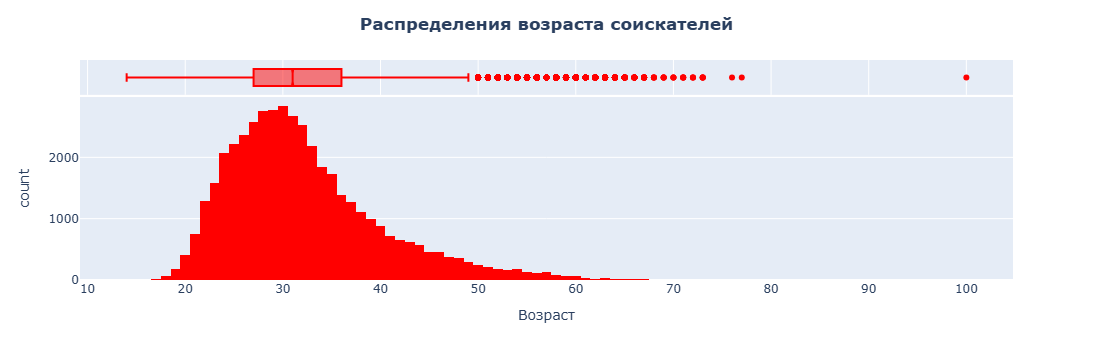

Чему равно модальное значение возраста соискателей? Ответ: 0    30
Name: Возраст, dtype: int64
Чему равен максимальный опыт работы (в месяцах)? Ответ: 1188.0


In [26]:
hh_data_temp = hh_data.copy()

fig = px.histogram(
    hh_data,
    x='Возраст',
    marginal='box',
    color_discrete_sequence=['red']
)
fig.update_layout(title_text='<b>Распределения возраста соискателей</b>', title_x=0.5)
fig.show()

#Ответ на контрольные вопросы
answer = hh_data['Возраст'].mode()
print(f'Чему равно модальное значение возраста соискателей? Ответ: {answer}')

answer = hh_data['Опыт работы (месяц)'].max()
print(f'Чему равен максимальный опыт работы (в месяцах)? Ответ: {answer}')

Вывод: Мода - наиболее часто встречающийся возраст соискателей - 30 лет. Максимальный возраст соискателя - 100 лет, а минимальный - 14 лет. Возраст большинства соискателей находится в промежутке от 27 до 36 лет. Минимальный возраст с которого работодатель может принять работника равен 16 годам, в исключительных случаях с 15 лет. Поэтому аномалиями можно считать резюме с указанным возрастом до 16 лет и максимальный возраст соискателя равный 100 годам.

2. Постройте распределение признака **"Опыт работы (месяц)"**. Опишите данное распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится опыт работы большинства соискателей? Есть ли аномалии для признака опыта работы, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

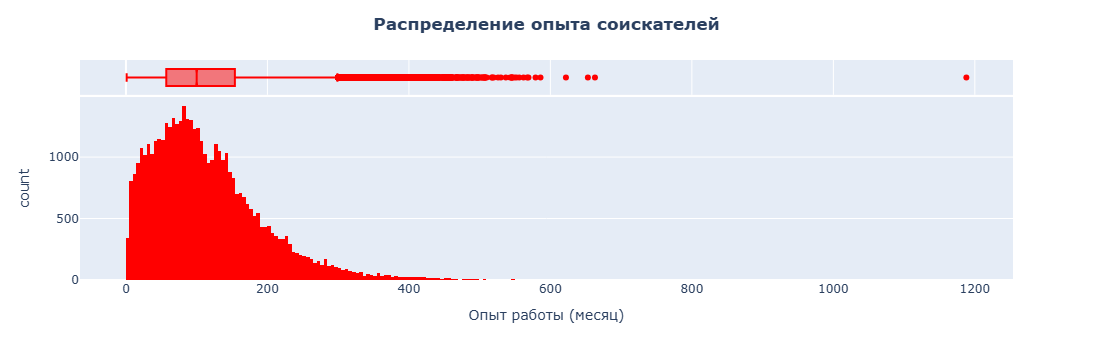

In [27]:
fig = px.histogram(
    hh_data,
    x='Опыт работы (месяц)',
    marginal='box',
    color_discrete_sequence=['red'],
)
fig.update_layout(title_text='<b>Распределение опыта соискателей</b>', title_x=0.5)
fig.show()

Вывод: Опыт работы соискателей сосредоточен в промежутке 57-154 месяца (рт 5 до 13 лет). Наиболее часто встречаются соискатели с опытом 80-84 месяца (7 лет). Самый большой опыт работы - 1188 месяцев (99 лет) скорее всего является выбросом.

3. Постройте распределение признака **"ЗП (руб)"**. Опишите данное распределение, отвечая на следующие вопросы: каковы предельные значения признака, в каком примерном интервале находится заработная плата большинства соискателей? Есть ли аномалии для признака возраста? Обратите внимание на гигантские размеры желаемой заработной платы.
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*


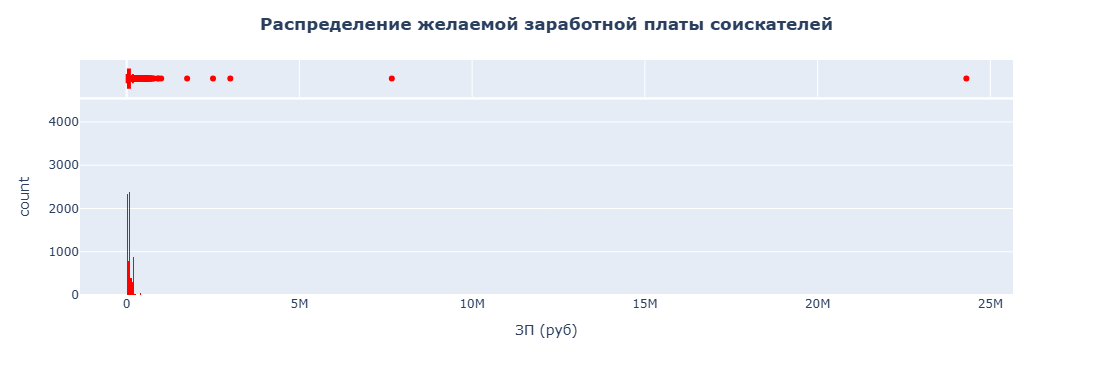

Определите по графику, сколько соискателей требуют заработную плату выше 1 миллиона рублей? Ответ: 5


In [28]:
fig = px.histogram(
    hh_data,
    x='ЗП (руб)',
    marginal='box',
    color_discrete_sequence=['red'],
    width=15000,
)
fig.update_layout(title_text='<b>Распределение желаемой заработной платы соискателей</b>', title_x=0.5)
fig.show()

#Ответ на контрольные вопросы
answer = hh_data[hh_data['ЗП (руб)']>1000000].shape[0]
print(f'Определите по графику, сколько соискателей требуют заработную плату выше 1 миллиона рублей? Ответ: {answer}')

Вывод: Заработная плата большинства соискателей сосредоточена в промежутке от 37 до 95 т.р. На графике видны выбросы в виде гигантских размеров заработной платы из-за чего график выглядит довольно растянутым. Мы уже знаем что наибольшее число соискателей имеют возраст 30 лет, с опытом работы около 7 лет желают получать з.п. от 37-95 т.р. В начале карьеры соискатели готовы работать за з.п. от 2.5 т.р.

4. Постройте диаграмму, которая показывает зависимость **медианной** желаемой заработной платы (**"ЗП (руб)"**) от уровня образования (**"Образование"**). Используйте для диаграммы данные о резюме, где желаемая заработная плата меньше 1 млн рублей.
*Сделайте выводы по представленной диаграмме: для каких уровней образования наблюдаются наибольшие и наименьшие уровни желаемой заработной платы? Как вы считаете, важен ли признак уровня образования при прогнозировании заработной платы?*

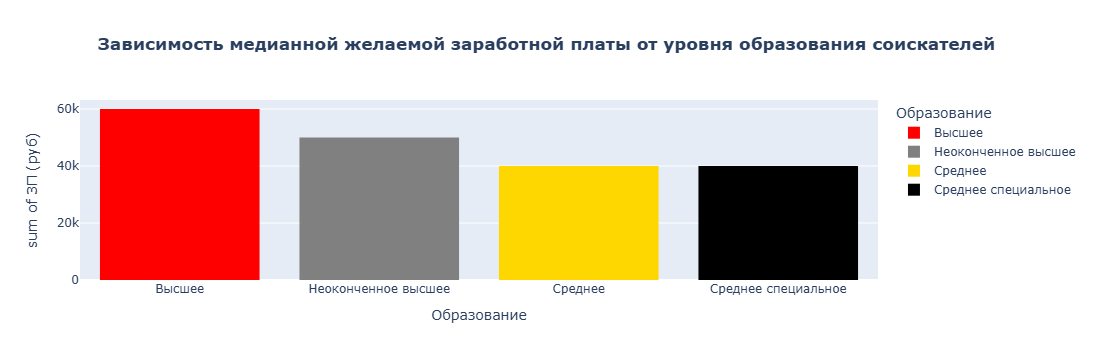

Какая категория образования оплачивается выше всех по медианному показателю? Ответ: Высшее


In [29]:
salary_education=hh_data[hh_data['ЗП (руб)']<1000000]
salary_education=salary_education.groupby('Образование', as_index=False)['ЗП (руб)'].median().sort_values('ЗП (руб)', ascending=False)
#display(salary_education)

fig = px.histogram(
    data_frame=salary_education,
    x='Образование',
    y='ЗП (руб)',
    color='Образование',
    title='Распределения желаемой заработной платы в зависимости от образования',
    color_discrete_sequence=["red", "grey", "gold", "black"],
)
fig.update_layout(title_text='<b>Зависимость медианной желаемой заработной платы от уровня образования соискателей</b>', title_x=0.5)
fig.show()

#Ответ на контрольные вопросы
salary_education=hh_data[hh_data['ЗП (руб)']<1000000]
answer = salary_education.groupby('Образование', as_index=False)['ЗП (руб)'].median().sort_values('ЗП (руб)', ascending=False)['Образование'].iloc[0]
print(f'Какая категория образования оплачивается выше всех по медианному показателю? Ответ: {answer}')

Вывод: есть прямая корреляция между увеличением уровня образования и заработной платой, наименьший уровень заработной платы у среднего и средне специального образования.

5. Постройте диаграмму, которая показывает распределение желаемой заработной платы (**"ЗП (руб)"**) в зависимости от города (**"Город"**). Используйте для диаграммы данные о резюме, где желая заработная плата меньше 1 млн рублей.
*Сделайте выводы по полученной диаграмме: как соотносятся медианные уровни желаемой заработной платы и их размах в городах? Как вы считаете, важен ли признак города при прогнозировании заработной платы?*

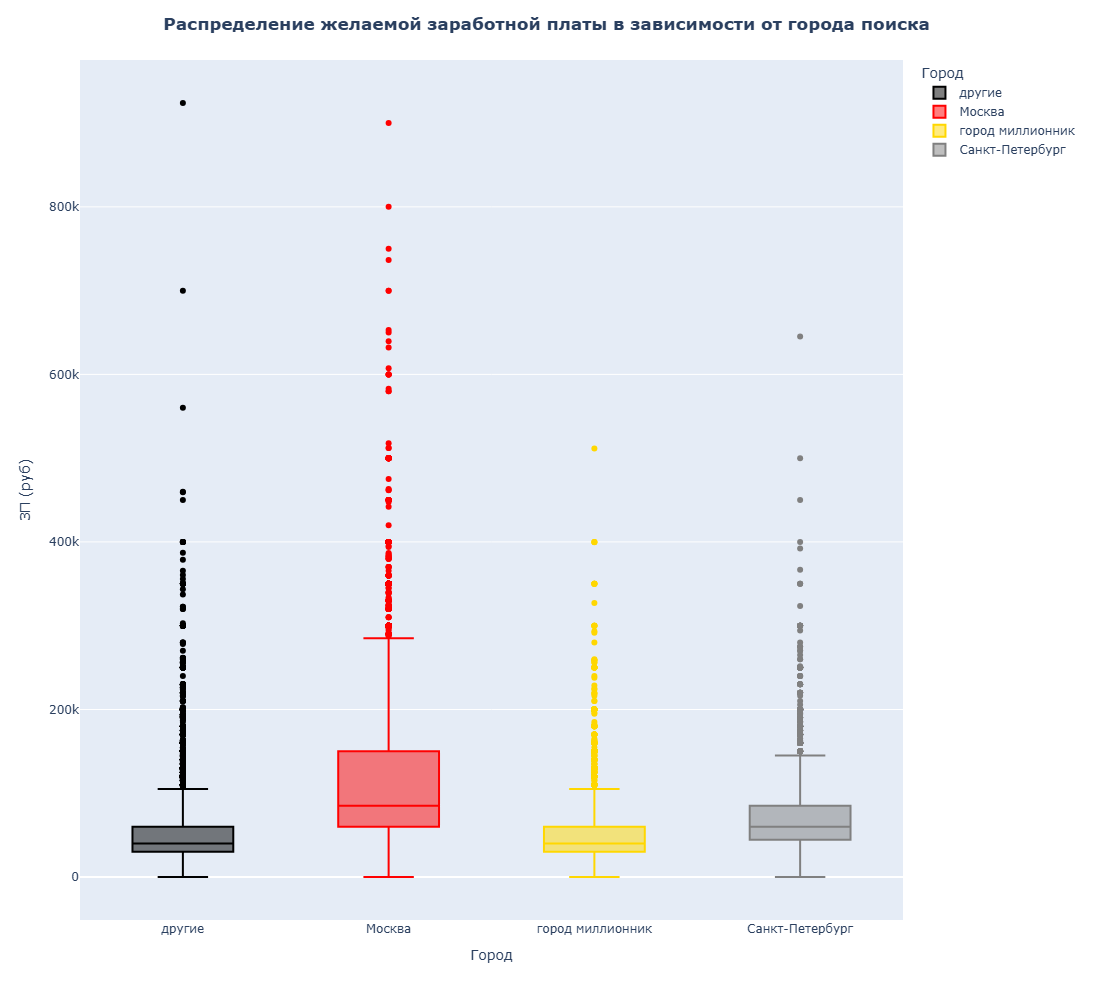

В каком городе (категории городов) зафиксирован наибольший показатель желаемой заработной платы (~924 тысячи рублей)? Ответ: другие


In [30]:
salary_sity=hh_data[hh_data['ЗП (руб)']<1000000]

fig = px.box(
    data_frame=salary_sity,
    x='Город',
    y='ЗП (руб)',
    labels={'Age':'Возраст', 'Exited':'Статус'},
    color='Город',
    color_discrete_sequence=["black", "red", "gold", "grey"],
    height=1000
)
fig.update_layout(title_text='<b>Распределение желаемой заработной платы в зависимости от города поиска</b>', title_x=0.5)
fig.show()

#Ответ на контрольные вопросы
salary_sity=hh_data[hh_data['ЗП (руб)']<1000000]
answer = salary_sity.groupby('Город', as_index=False)['ЗП (руб)'].max().sort_values('ЗП (руб)', ascending=False)['Город'].iloc[0]
print(f'В каком городе (категории городов) зафиксирован наибольший показатель желаемой заработной платы (~924 тысячи рублей)? Ответ: {answer}')
#display(salary_sity.groupby('Город', as_index=False)['ЗП (руб)'].max().sort_values('ЗП (руб)', ascending=False))

Лидером по медианной зарплате является Москва (85 тыс. руб.), за ней следует Санкт-Петербург (60 тыс. руб.). В двух оставшихся категориях медианное значение желаемого дохода одинаково (40 тыс. руб.). Максимальный выброс зафиксирован в группе «другие» — около 942 тыс. руб. Самый высокий разброс значений желаемой зарплаты наблюдается у Москвы.

6. Постройте **многоуровневую столбчатую диаграмму**, которая показывает зависимость медианной заработной платы (**"ЗП (руб)"**) от признаков **"Готовность к переезду"** и **"Готовность к командировкам"**. Проанализируйте график, сравнив уровень заработной платы в категориях.

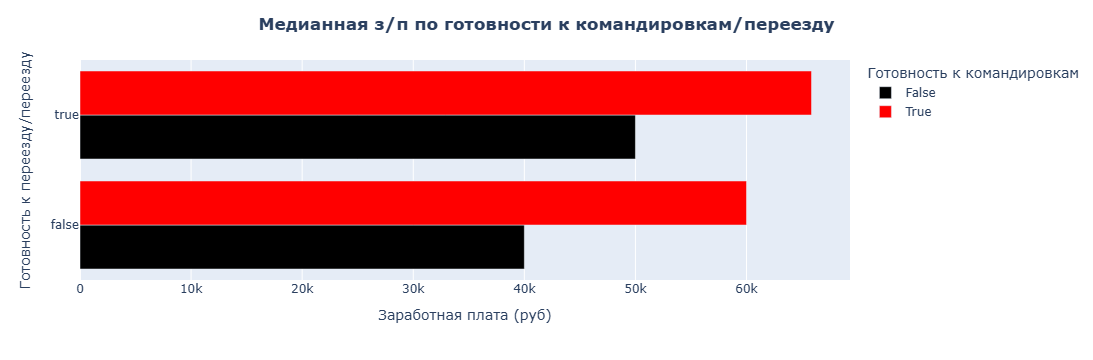

Чему равна желаемая медианная заработная плата соискателей, готовых и к переезду, и к командировкам? Ответ приведите в тысячах, округлив до целого (например, 45)? Ответ: 66.0


In [31]:
salary_transfer = hh_data.groupby(
    ['Готовность к командировкам', 'Готовность к переезду'],
    as_index=False
)['ЗП (руб)'].median()

fig = px.bar(
    data_frame=salary_transfer,
    y='Готовность к переезду',
    x='ЗП (руб)',
    barmode="group",
    labels={'Готовность к переезду':'Готовность к переезду/переезду', 'ЗП (руб)': 'Заработная плата (руб)'},
    color='Готовность к командировкам',
    orientation='h',
    color_discrete_sequence=["black", "red"],
)
fig.update_layout(title_text='<b>Медианная з/п по готовности к командировкам/переезду</b>', title_x=0.5)
fig.show()

#Ответ на контрольные вопросы
answer = salary_transfer[(salary_transfer['Готовность к командировкам']==True) & (salary_transfer['Готовность к переезду']==True)]['ЗП (руб)'].iloc[0]/1000
print(f'Чему равна желаемая медианная заработная плата соискателей, готовых и к переезду, и к командировкам? Ответ приведите в тысячах, округлив до целого (например, 45)? Ответ: {round(answer,0)}')
#display(salary_transfer)

In [ ]:
Желаемая зарплата выше у тех, кто готов к переездам и командировкам. Командировки ценятся дороже: вероятно, из-за дополнительных выплат и того факта, что в них отправляют более высокопоставленных сотрудников. Переезд тоже повышает зарплатные ожидания — скорее всего, из-за планов мигрировать в крупные города за лучшим качеством жизни.

7. Постройте сводную таблицу, иллюстрирующую зависимость **медианной** желаемой заработной платы от возраста (**"Возраст"**) и образования (**"Образование"**). На полученной сводной таблице постройте **тепловую карту**. Проанализируйте тепловую карту, сравнив показатели внутри групп.

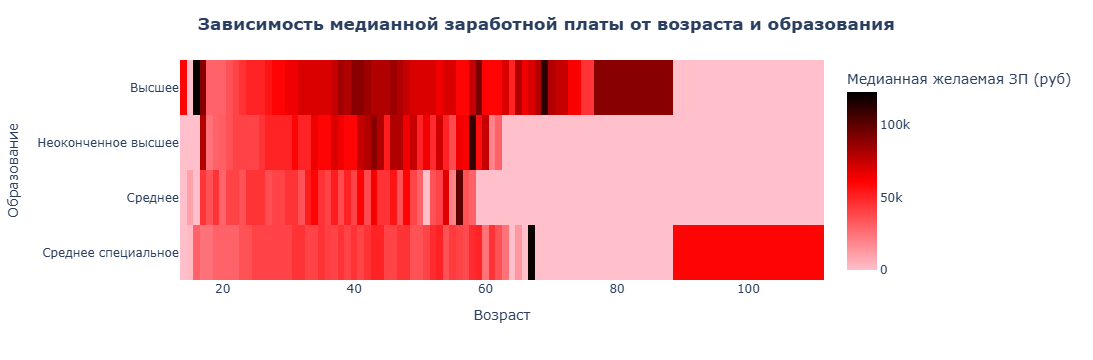

In [32]:
#Построение сводной таблицы иллюстрирующую зависимость медианной желаемой заработной платы от Возраста и Образования
salary_age=pd.pivot_table(
    hh_data, 
    index='Образование', 
    columns='Возраст', 
    values='ЗП (руб)', 
    aggfunc='median',
    fill_value=0
)

fig = px.imshow(
    img=salary_age,
    labels={'color': 'Медианная желаемая ЗП (руб)'},
    aspect='equal',
    color_continuous_scale=["pink", "red", "black"]
)

fig.update_layout(title_text='<b>Зависимость медианной заработной платы от возраста и образования</b>', title_x=0.5)
fig.show()

Лидер по темпу роста зарплатных ожиданий — категория с высшим образованием.
Выбросы на тепловой карте: в 14 лет (60 тыс.), в 16 лет (122 тыс.) для высшего образования; для средне-специального — соискатель 100 лет и выброс 120 тыс.
Во всех категориях есть пропуски по желаемой зарплате.
До 40–45 лет — плавный рост ожиданий (карьера, опыт), затем плавный спад. В категориях среднего и средне-специального образования динамика сглажена.

8. Постройте **диаграмму рассеяния**, показывающую зависимость опыта работы (**"Опыт работы (месяц)"**) от возраста (**"Возраст"**). Опыт работы переведите из месяцев в года, чтобы признаки были в едином масштабе. Постройте на графике дополнительно прямую, проходящую через точки (0, 0) и (100, 100). Данная прямая соответствует значениям, когда опыт работы равен возрасту человека. Точки, лежащие на этой прямой и выше нее - аномалии в наших данных (опыт работы больше либо равен возрасту соискателя)

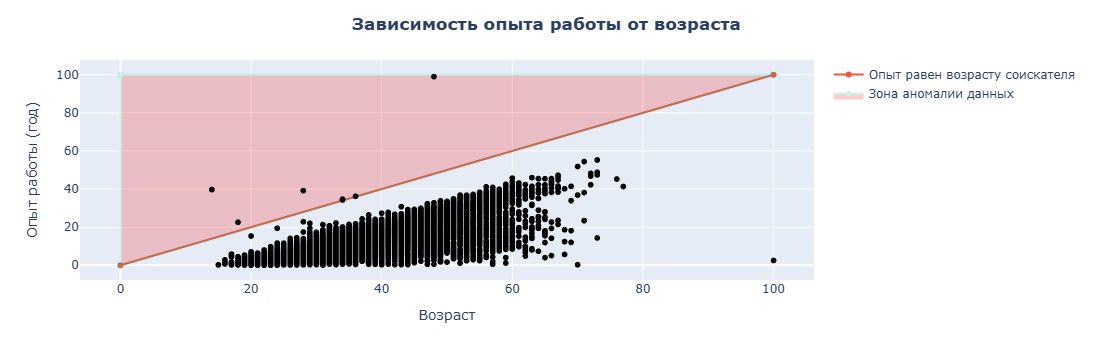

Сколько точек лежат строго выше построенной прямой? Ответ: 7


In [35]:
experience_age=hh_data.copy()
experience_age['Опыт работы (год)']=experience_age['Опыт работы (месяц)']/12

x=[0,100]
y=[0,100]
fig = px.scatter(
    data_frame=experience_age,
    x='Возраст',
    y='Опыт работы (год)',
    color_discrete_sequence=["black"]
)

#Второй способ объединить графики используя plotly
#fig1 = px.scatter(data_frame=experience_age, x='Возраст',y='Опыт работы (год)',color_discrete_sequence=["black"])
#fig2 = px.line(x=x, y=y, color_discrete_sequence=["red"])
#fig=go.Figure(data = fig1.data + fig2.data)

fig.update_layout(title_text='<b>Зависимость опыта работы от возраста</b>', title_x=0.5)
fig.add_trace(
    go.Scatter(x=[0, 100], y=[0, 100], name="Опыт равен возрасту соискателя"),
    secondary_y=False,
)
fig.add_trace(
    go.Scatter(x=[0, 100, 0, 0], y=[0, 100, 100, 0], name="Зона аномалии данных", fill="toself", fillcolor="red", opacity=0.2),
    secondary_y=False,
)
fig.show()

#Ответ на контрольные вопросы
answer = experience_age[experience_age['Опыт работы (год)']>=experience_age['Возраст']]
print(f'Сколько точек лежат строго выше построенной прямой? Ответ: {answer.shape[0]}')

На графике прослеживается четкая прямая связь между возрастом соискателя и его опытом: чем старше кандидат, тем больше у него стажа. Расстояние от точек до теоретической линии остается примерно постоянным — это период жизни, когда накопление опыта невозможно, а именно возраст от рождения до окончания учебы (0–17 лет). Точки, расположенные выше линии, указывают на аномалию: опыт превышает возраст соискателя. После 67 лет количество кандидатов резко сокращается, поэтому всех соискателей старше этого возраста можно считать выбросами.

**Дополнительные баллы**

Для получения 2 дополнительных баллов по разведывательному анализу постройте еще два любых содержательных графика или диаграммы, которые помогут проиллюстрировать влияние признаков/взаимосвязь между признаками/распределения признаков. Приведите выводы по ним. Желательно, чтобы в анализе участвовали признаки, которые мы создавали ранее в разделе "Преобразование данных".


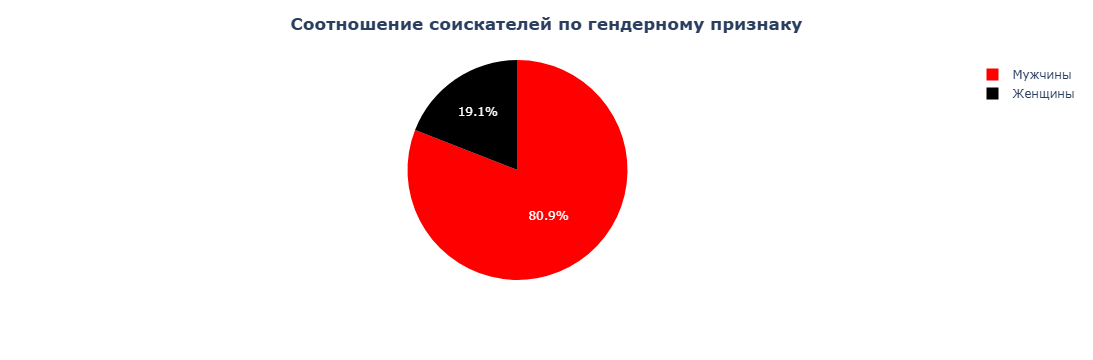

In [36]:
#Соотношение количества резюме по гендерному признаку 
hh_data_gender = hh_data.groupby('Пол').size()

fig = px.pie(
    data_frame=hh_data,
    values=hh_data_gender,
    names=['Женщины', 'Мужчины'],
    color_discrete_sequence=["red", "black"]
)
fig.update_layout(title_text='<b>Соотношение соискателей по гендерному признаку</b>', title_x=0.5)
fig.show()

ваши выводы здесь

# Очистка данных

1. Начнем с дубликатов в наших данных. Найдите **полные дубликаты** в таблице с резюме и удалите их. 

In [37]:
#display(hh_data.info())
dupl_columns = list(hh_data.columns)
mask = hh_data.duplicated(subset=dupl_columns)
hh_duplicates = hh_data[mask]
print(f'Изначальное число записей: {hh_data.shape[0]}')
print(f'Число найденных дубликатов: {hh_duplicates.shape[0]}')
hh_dedupped = hh_data.drop_duplicates(subset=dupl_columns)
print(f'Результирующее число записей: {hh_dedupped.shape[0]}')

Изначальное число записей: 44744
Число найденных дубликатов: 161
Результирующее число записей: 44583


2. Займемся пропусками. Выведите информацию **о числе пропусков** в столбцах. 

In [38]:
cols_null = hh_dedupped.isnull().sum()
display(cols_null[cols_null>0])

Последнее/нынешнее место работы      1
Последняя/нынешняя должность         2
Опыт работы (месяц)                168
dtype: int64

3. Итак, у нас есть пропуски в 3ех столбцах: **"Опыт работы (месяц)"**, **"Последнее/нынешнее место работы"**, **"Последняя/нынешняя должность"**. Поступим следующим образом: удалите строки, где есть пропуск в столбцах с местом работы и должностью. Пропуски в столбце с опытом работы заполните **медианным** значением.

In [40]:
hh_dedupped = hh_dedupped.dropna(subset=['Последнее/нынешнее место работы', 'Последняя/нынешняя должность'])
hh_dedupped['Опыт работы (месяц)'] = hh_dedupped['Опыт работы (месяц)'].fillna(hh_dedupped['Опыт работы (месяц)'].median())

4. Мы добрались до ликвидации выбросов. Сначала очистим данные вручную. Удалите резюме, в которых указана заработная плата либо выше 1 млн. рублей, либо ниже 1 тыс. рублей.

In [41]:
outliers = hh_dedupped[(hh_dedupped['ЗП (руб)'] > 1000000) | (hh_dedupped['ЗП (руб)']<1000)]
print(outliers.shape[0])
hh_dedupped = hh_dedupped.drop(outliers.index, axis=0)
print(f'Результирующее число записей: {hh_dedupped.shape[0]}')

89
Результирующее число записей: 44492


5. В процессе разведывательного анализа мы обнаружили резюме, в которых **опыт работы в годах превышал возраст соискателя**. Найдите такие резюме и удалите их из данных


In [42]:
outliers = hh_dedupped[(hh_dedupped['Опыт работы (месяц)']/12)>hh_dedupped['Возраст']]
print(f'Аномалии данных (опыт работы больше либо равен возрасту соискателя): {outliers.shape[0]}')
hh_dedupped = hh_dedupped.drop(outliers.index, axis=0)
print(f'Результирующее число записей: {hh_dedupped.shape[0]}')

Аномалии данных (опыт работы больше либо равен возрасту соискателя): 7
Результирующее число записей: 44485


6. В результате анализа мы обнаружили потенциальные выбросы в признаке **"Возраст"**. Это оказались резюме людей чересчур преклонного возраста для поиска работы. Попробуйте построить распределение признака в **логарифмическом масштабе**. Добавьте к графику линии, отображающие **среднее и границы интервала метода трех сигм**. Напомним, сделать это можно с помощью метода axvline. Например, для построение линии среднего будет иметь вид:

`histplot.axvline(log_age.mean(), color='k', lw=2)`

В какую сторону асимметрично логарифмическое распределение? Напишите об этом в комментарии к графику.
Найдите выбросы с помощью метода z-отклонения и удалите их из данных, используйте логарифмический масштаб. Давайте сделаем послабление на **1 сигму** (возьмите 4 сигмы) в **правую сторону**.

Выведите таблицу с полученными выбросами и оцените, с каким возрастом соискатели попадают под категорию выбросов?

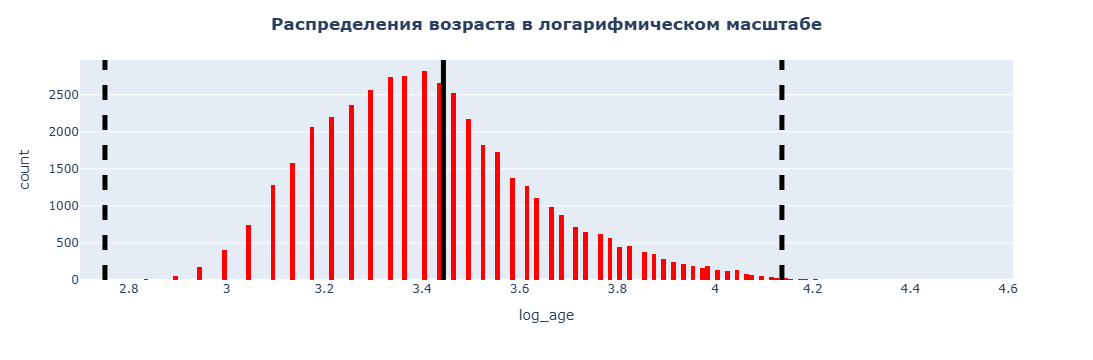

Число выбросов по методу z-отклонения: 3
Результирующее число записей: 44482


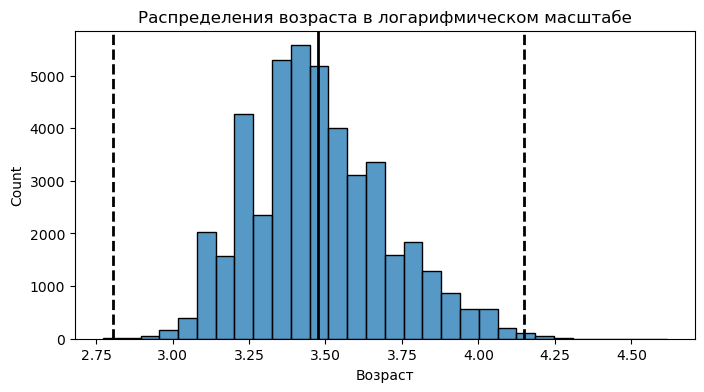

In [43]:
#Правило трёх сигм, параметры left и right задают число сигм (стандартных отклонений) влево и вправо соответственно, определяющее границы метода z-отклонения.
def outliers_z_score_mod(data, feature, log_scale=False, left=3, right=3):
    if log_scale:
        x = np.log(data[feature]+1)
    else:
        x = data[feature]
    mu = x.mean()
    sigma = x.std()
    lower_bound = mu - (left * sigma)
    upper_bound = mu + (right * sigma)
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x > lower_bound) & (x < upper_bound)]
    return outliers, cleaned

log_age = pd.DataFrame(hh_dedupped,columns=['Возраст'])
log_age['log_age'] = np.log(hh_dedupped['Возраст'])

fig = px.histogram(
    data_frame=log_age,
    x='log_age',
    #labels={'Balance':'Баланс', 'Exited': 'Статус', 'y':'Количество'},
    color_discrete_sequence=["red"],
    #nbins = 30
)

fig.add_vline(x=log_age['log_age'].mean(), line_width=5, line_color="black")
fig.add_vline(x=log_age['log_age'].mean()-(3*log_age['log_age'].std()), line_width=5, line_dash="dash", line_color="black")
fig.add_vline(x=log_age['log_age'].mean()+(3*log_age['log_age'].std()), line_width=5, line_dash="dash", line_color="black")

fig.update_layout(title_text='<b>Распределения возраста в логарифмическом масштабе</b>', title_x=0.5)
fig.show()

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
log_age_math = np.log(hh_dedupped['Возраст'] + 1)
histplot = sns.histplot(log_age_math, bins=30, ax=ax)
histplot.axvline(log_age_math.mean(), color='k', lw=2)
histplot.axvline(log_age_math.mean()+ 3 * log_age_math.std(), color='k', ls='--', lw=2)
histplot.axvline(log_age_math.mean()- 3 * log_age_math.std(), color='k', ls='--', lw=2)
histplot.set_title('Распределения возраста в логарифмическом масштабе');

outliers, cleaned = outliers_z_score_mod(hh_dedupped, 'Возраст', log_scale=True, right=4)
print(f'Число выбросов по методу z-отклонения: {outliers.shape[0]}')
print(f'Результирующее число записей: {cleaned.shape[0]}')

Распределение имеет отклонение в правую сторону и составляет около 0.5